# Movie Genre Classification from Posters

Can a CNN tell a movie's genre from its poster alone? This notebook classifies posters as **Action, Comedy, Horror or Romance** with transfer learning in PyTorch. It compares four ImageNet-pretrained backbones as frozen feature extractors, then tests whether fine-tuning the best one helps.

With only 1,325 posters, a single 199-image test set is too noisy to rank models: one test split has a 95% confidence interval of about ±6.5 points. Every experiment is therefore repeated on **5 different stratified train/val/test splits**, and results are reported as **mean ± standard deviation**.

| | |
|---|---|
| **Dataset** | [Four-Genre Movie Poster Images](https://www.kaggle.com/datasets/zulkarnainsaurav/four-genre-movie-poster-images) (Kaggle, Apache 2.0): 1,325 IMDB posters |
| **Protocol** | 5 repeats of a stratified 70 / 15 / 15 split (seeds 0–4). Each run checkpoints the epoch with the lowest **validation loss**. Configurations are chosen on **mean validation accuracy**. Test sets are used only for reporting. |
| **Stage 1** | Frozen backbone with a new linear head: ResNet18 · ResNet50 · DenseNet121 · VGG16 |
| **Stage 2** | Fine-tune the last block of the stage-1 winner with regularization: discriminative learning rates, weight decay, label smoothing, stronger augmentation and early stopping |
| **Code** | Shared data, model and training code lives in the [`postergenre/`](postergenre) package. The [demo app](app.py) and the [tests](tests) use the same code. |

## 1. Setup

In [1]:
import sys, os
if "google.colab" in sys.modules and not os.path.exists("postergenre"):  # Colab: fetch the repo's package
    !git clone -q https://github.com/RachitSethi2455/movie-genre-poster-classification.git
    %cd movie-genre-poster-classification
    !pip install -q kagglehub

In [2]:
import json
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader

from postergenre.data import (ImageCache, PosterDataset, download_posters, eval_tf, finetune_tf, list_images,
                              load_image, stratified_split, train_tf)
from postergenre.models import (BACKBONES, build_model, count_params, param_groups, trained_state,
                                unfreeze_last_block)
from postergenre.train import fit, predict, seed_everything

SPLIT_SEEDS = [0, 1, 2, 3, 4]
EPOCHS, BATCH_SIZE = 8, 32
ASSETS, MODELS = Path("assets"), Path("models")
ASSETS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")
print("Device:", device, f"({torch.cuda.get_device_name(0)})" if device.type == "cuda" else "")

Device: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


## 2. Data
`download_posters()` fetches the dataset from Kaggle on first use. Every poster is then decoded and resized to 224×224 **once** and kept in memory (about 200 MB). Reading JPEGs from disk on every epoch was the bottleneck in earlier versions.

In [3]:
root = download_posters()
paths, labels, class_names = list_images(root)
print(pd.Series([class_names[l] for l in labels]).value_counts().rename("posters").to_frame().T.to_string())
print("Total:", len(paths))

start = time.time()
cache = ImageCache(paths)
print(f"Cached {len(cache)} posters in {time.time() - start:.0f}s")

split_sizes = {s: {k: len(v[0]) for k, v in stratified_split(paths, labels, s).items()} for s in SPLIT_SEEDS}
pd.DataFrame(split_sizes).T.rename_axis("split seed")

         Horror  Action  Comedy  Romance
posters     398     337     321      269
Total: 1325


Cached 1325 posters in 6s


,train,val,test
split seed,,,
0,927,199,199
1,927,199,199
2,927,199,199
3,927,199,199
4,927,199,199


### A look at the data

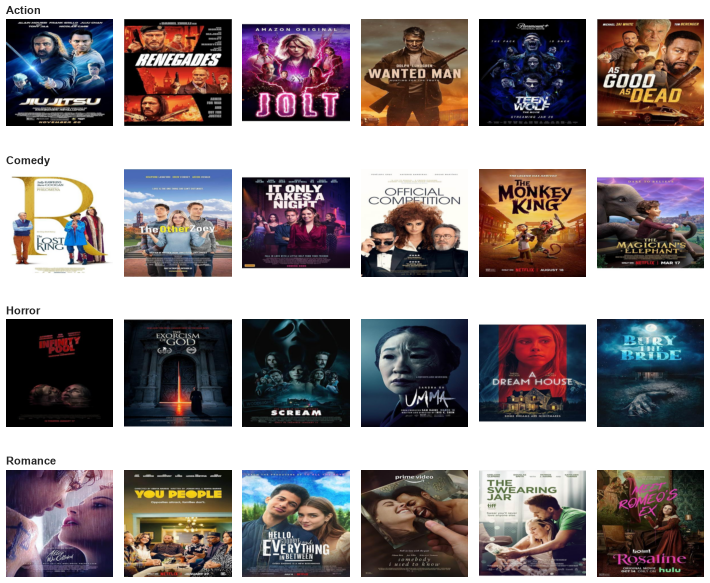

In [4]:
rng = random.Random(42)
with plt.rc_context({"figure.dpi": 60}):  # thumbnails: keep the notebook small
    fig, axes = plt.subplots(len(class_names), 6, figsize=(12, 2.6 * len(class_names)))
    for r, genre in enumerate(class_names):
        genre_paths = [p for p, l in zip(paths, labels) if l == r]
        for c, path in enumerate(rng.sample(genre_paths, 6)):
            axes[r, c].imshow(cache[path])
            axes[r, c].axis("off")
        axes[r, 0].set_title(genre, loc="left", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 3. Stage 1: frozen backbones on 5 splits

For each split seed and each backbone: freeze all pretrained weights, train a new linear head (Adam, lr 1e-3, 8 epochs, batch size 32) and keep the epoch with the lowest validation loss. That checkpoint is then scored on the split's validation and test sets. Only the head and the BatchNorm statistics change, so each checkpoint is a few hundred KB and fits in memory.

In [5]:
def loaders(seed, train_transform):
    split = stratified_split(paths, labels, seed)
    g = torch.Generator().manual_seed(seed)
    make = lambda part, tf, shuffle: DataLoader(PosterDataset(*split[part], cache, tf), batch_size=BATCH_SIZE,
                                                shuffle=shuffle, generator=g if shuffle else None,
                                                pin_memory=device.type == "cuda")
    return make("train", train_transform, True), make("val", eval_tf, False), make("test", eval_tf, False)


runs, histories, states, preds = [], {}, {}, {}
for seed in SPLIT_SEEDS:
    train_loader, val_loader, test_loader = loaders(seed, train_tf)
    for name in BACKBONES:
        seed_everything(seed)
        model = build_model(name, len(class_names)).to(device)
        history, best = fit(model, train_loader, val_loader, device, param_groups(model, name, 1e-3, 0),
                            EPOCHS, name=f"{name} / split {seed}", verbose=False)
        y_true, y_pred, probs = predict(model, test_loader, device)
        runs.append({"Backbone": name, "Split": seed, "Val acc": best["val_acc"], "Val loss": best["val_loss"],
                     "Best epoch": best["epoch"], "Test acc": 100 * (y_true == y_pred).mean(),
                     "Test macro-F1": f1_score(y_true, y_pred, average="macro"), "Seconds": best["seconds"]})
        histories[name, seed], states[name, seed], preds[name, seed] = history, trained_state(model), (y_true, y_pred, probs)
        print(f"split {seed} | {name:<11} val {best['val_acc']:5.1f}%  test {runs[-1]['Test acc']:5.1f}%  "
              f"(epoch {best['epoch']}, {best['seconds']:.0f}s)")
        del model
        torch.cuda.empty_cache()

runs = pd.DataFrame(runs)

split 0 | ResNet18    val  63.8%  test  65.3%  (epoch 7, 35s)


split 0 | ResNet50    val  63.3%  test  70.4%  (epoch 8, 104s)


split 0 | DenseNet121 val  64.8%  test  62.3%  (epoch 6, 61s)


split 0 | VGG16       val  64.8%  test  66.3%  (epoch 1, 81s)


split 1 | ResNet18    val  67.8%  test  63.8%  (epoch 8, 30s)


...

split 3 | VGG16       val  67.8%  test  61.3%  (epoch 4, 63s)


split 4 | ResNet18    val  61.8%  test  65.8%  (epoch 8, 23s)


split 4 | ResNet50    val  70.9%  test  68.8%  (epoch 8, 41s)


split 4 | DenseNet121 val  64.3%  test  67.8%  (epoch 7, 44s)


split 4 | VGG16       val  69.3%  test  66.3%  (epoch 3, 62s)


### Results across the 5 splits

In [6]:
params = {name: count_params(build_model(name, len(class_names), pretrained=False)) for name in BACKBONES}
stage1 = (runs.groupby("Backbone")
          .agg(**{"Val acc": ("Val acc", "mean"), "Val acc sd": ("Val acc", "std"),
                  "Test acc": ("Test acc", "mean"), "Test acc sd": ("Test acc", "std"),
                  "Test macro-F1": ("Test macro-F1", "mean"), "Train time / run (s)": ("Seconds", "mean")})
          .sort_values("Val acc", ascending=False))
stage1.insert(0, "Trainable / total params", [f"{params[b][0] / 1e3:.1f}K / {params[b][1] / 1e6:.1f}M" for b in stage1.index])
best_backbone = stage1.index[0]
print("Chosen on mean validation accuracy:", best_backbone)
stage1.style.format({"Val acc": "{:.1f}%", "Val acc sd": "±{:.1f}", "Test acc": "{:.1f}%", "Test acc sd": "±{:.1f}",
                     "Test macro-F1": "{:.3f}", "Train time / run (s)": "{:.0f}"})

Chosen on mean validation accuracy: ResNet50


,Trainable / total params,Val acc,Val acc sd,Test acc,Test acc sd,Test macro-F1,Train time / run (s)
Backbone,,,,,,,
ResNet50,8.2K / 23.5M,69.0%,±3.5,69.6%,±1.2,0.684,56
VGG16,16.4K / 134.3M,66.7%,±2.5,64.1%,±2.2,0.627,68
DenseNet121,4.1K / 7.0M,65.7%,±1.9,66.1%,±2.7,0.646,49
ResNet18,2.1K / 11.2M,62.7%,±3.8,65.7%,±4.1,0.641,26


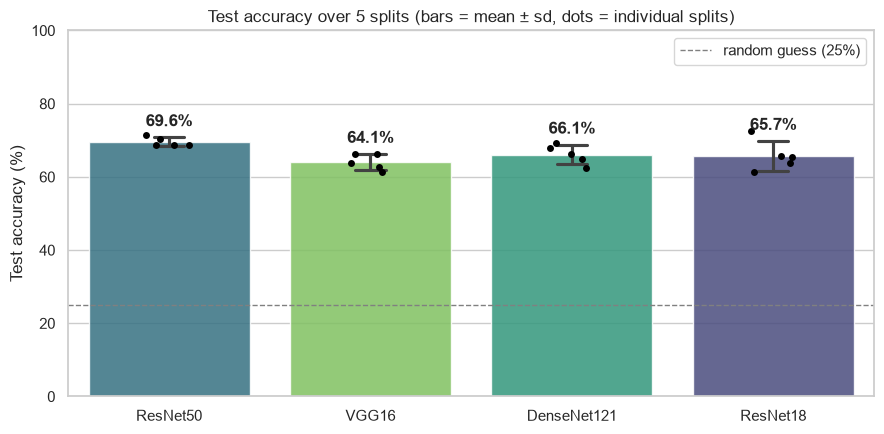

In [7]:
order = list(stage1.index)
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=runs, x="Backbone", y="Test acc", hue="Backbone", order=order, palette="viridis",
            errorbar="sd", capsize=0.15, legend=False, ax=ax, alpha=0.85)
sns.stripplot(data=runs, x="Backbone", y="Test acc", order=order, color="black", size=5, jitter=0.12, ax=ax)
ax.axhline(100 / len(class_names), color="grey", ls="--", lw=1, label="random guess (25%)")
for i, b in enumerate(order):
    ax.text(i, stage1.loc[b, "Test acc"] + stage1.loc[b, "Test acc sd"] + 3, f"{stage1.loc[b, 'Test acc']:.1f}%",
            ha="center", fontweight="bold")
ax.legend(loc="upper right")
ax.set(ylim=(0, 100), xlabel="", ylabel="Test accuracy (%)",
       title="Test accuracy over 5 splits (bars = mean ± sd, dots = individual splits)")
plt.tight_layout()
plt.savefig(ASSETS / "backbone_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

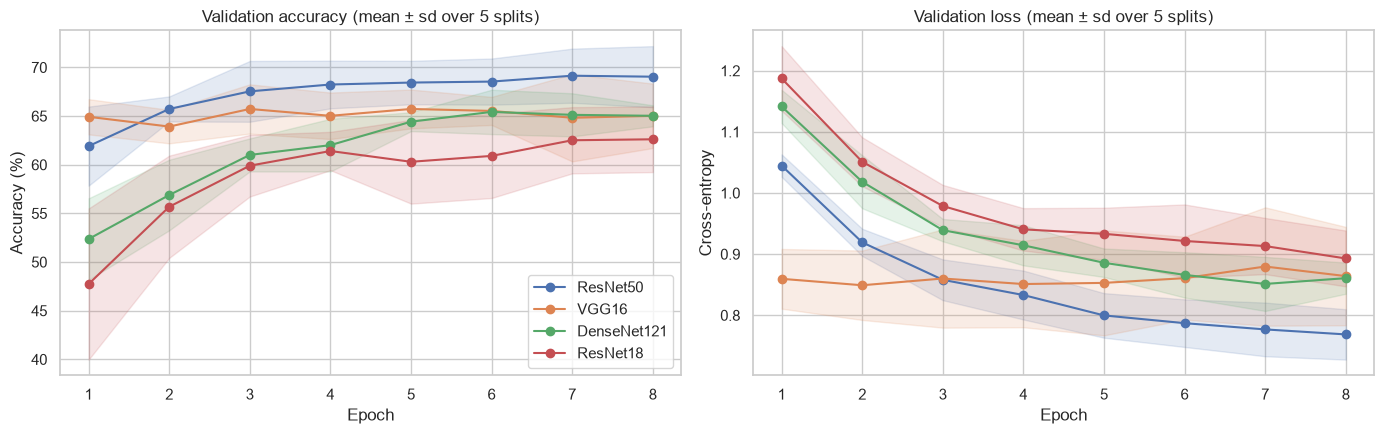

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for name in order:
    acc = np.array([histories[name, s]["val_acc"] for s in SPLIT_SEEDS])
    loss = np.array([histories[name, s]["val_loss"] for s in SPLIT_SEEDS])
    ep = np.arange(1, EPOCHS + 1)
    for ax, vals in ((axes[0], acc), (axes[1], loss)):
        line, = ax.plot(ep, vals.mean(0), marker="o", label=name)
        ax.fill_between(ep, vals.mean(0) - vals.std(0), vals.mean(0) + vals.std(0), color=line.get_color(), alpha=0.15)
axes[0].set(title="Validation accuracy (mean ± sd over 5 splits)", xlabel="Epoch", ylabel="Accuracy (%)")
axes[1].set(title="Validation loss (mean ± sd over 5 splits)", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()
plt.tight_layout()
plt.savefig(ASSETS / "learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Stage 2: does fine-tuning help?

Here the last block of the stage-1 winner is unfrozen and trained together with the head, starting from that split's stage-1 checkpoint. An earlier version fine-tuned with a single learning rate of 1e-4 and overfit within two epochs (94% train vs ~68% validation). This version adds regularization:

- **discriminative learning rates**: 3e-4 for the head and 3e-5 for the backbone block
- **weight decay** of 1e-4 (AdamW) and **label smoothing** of 0.1
- **stronger augmentation**: random resized crops and more colour jitter
- **early stopping** after 3 epochs without improvement in validation loss, with at most 12 epochs

In [9]:
ft_runs = []
for seed in SPLIT_SEEDS:
    train_loader, val_loader, test_loader = loaders(seed, finetune_tf)
    seed_everything(seed)
    model = build_model(best_backbone, len(class_names)).to(device)
    model.load_state_dict(states[best_backbone, seed], strict=False)
    unfreeze_last_block(model, best_backbone)
    history, best = fit(model, train_loader, val_loader, device, param_groups(model, best_backbone, 3e-4, 3e-5),
                        epochs=12, weight_decay=1e-4, label_smoothing=0.1, patience=3,
                        name=f"{best_backbone} fine-tune / split {seed}", verbose=False)
    y_true, y_pred, probs = predict(model, test_loader, device)
    frozen = runs[(runs["Backbone"] == best_backbone) & (runs["Split"] == seed)].iloc[0]
    ft_runs.append({"Split": seed, "Frozen val acc": frozen["Val acc"], "Fine-tuned val acc": best["val_acc"],
                    "Frozen test acc": frozen["Test acc"], "Fine-tuned test acc": 100 * (y_true == y_pred).mean(),
                    "Fine-tuned test macro-F1": f1_score(y_true, y_pred, average="macro"),
                    "Epochs run": len(history["val_loss"]), "Best epoch": best["epoch"],
                    "Final train acc": history["train_acc"][-1]})
    histories["finetuned", seed], preds["finetuned", seed] = history, (y_true, y_pred, probs)
    if seed == SPLIT_SEEDS[0]:
        demo_state = trained_state(model)
    print(f"split {seed} | val {frozen['Val acc']:.1f}% -> {best['val_acc']:.1f}%   "
          f"test {frozen['Test acc']:.1f}% -> {ft_runs[-1]['Fine-tuned test acc']:.1f}%   "
          f"(stopped after {len(history['val_loss'])} epochs, best {best['epoch']})")
    del model
    torch.cuda.empty_cache()

ft = pd.DataFrame(ft_runs).set_index("Split")
ft.loc["mean"] = ft.mean()
ft.loc["sd"] = ft.drop(index="mean").std()
ft.style.format("{:.1f}", subset=[c for c in ft.columns if "acc" in c]).format("{:.3f}", subset=["Fine-tuned test macro-F1"]) \
        .format("{:.0f}", subset=["Epochs run", "Best epoch"])

split 0 | val 63.3% -> 67.3%   test 70.4% -> 69.3%   (stopped after 5 epochs, best 2)


split 1 | val 70.4% -> 72.4%   test 71.4% -> 70.9%   (stopped after 9 epochs, best 6)


split 2 | val 72.4% -> 68.3%   test 68.8% -> 68.8%   (stopped after 7 epochs, best 4)


split 3 | val 68.3% -> 66.8%   test 68.8% -> 66.8%   (stopped after 4 epochs, best 1)


split 4 | val 70.9% -> 74.4%   test 68.8% -> 69.3%   (stopped after 6 epochs, best 3)


,Frozen val acc,Fine-tuned val acc,Frozen test acc,Fine-tuned test acc,Fine-tuned test macro-F1,Epochs run,Best epoch,Final train acc
Split,,,,,,,,
0,63.3,67.3,70.4,69.3,0.681,5,2,85.1
1,70.4,72.4,71.4,70.9,0.701,9,6,89.6
2,72.4,68.3,68.8,68.8,0.679,7,4,87.8
3,68.3,66.8,68.8,66.8,0.654,4,1,80.9
4,70.9,74.4,68.8,69.3,0.682,6,3,86.6
mean,69.0,69.8,69.6,69.0,0.679,6,3,86.0
sd,3.5,3.3,1.2,1.4,0.017,2,2,3.3


Mean validation gain from fine-tuning: +0.8 pts (sd 3.5), better on 3/5 splits
Mean test gain from fine-tuning:       -0.6 pts (sd 1.0), better on 1/5 splits
Final configuration (chosen on validation): ResNet50 (fine-tuned)


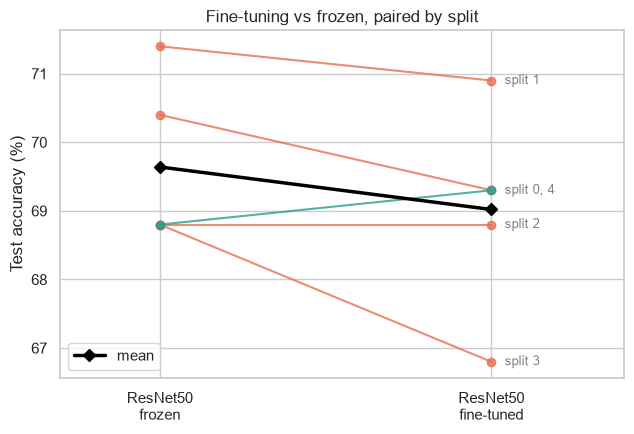

In [10]:
per_split = ft.drop(index=["mean", "sd"])
val_gain = per_split["Fine-tuned val acc"] - per_split["Frozen val acc"]
test_gain = per_split["Fine-tuned test acc"] - per_split["Frozen test acc"]
use_finetuned = val_gain.mean() > 0
final_name = f"{best_backbone} ({'fine-tuned' if use_finetuned else 'frozen'})"
print(f"Mean validation gain from fine-tuning: {val_gain.mean():+.1f} pts (sd {val_gain.std():.1f}), "
      f"better on {(val_gain > 0).sum()}/5 splits")
print(f"Mean test gain from fine-tuning:       {test_gain.mean():+.1f} pts (sd {test_gain.std():.1f}), "
      f"better on {(test_gain > 0).sum()}/5 splits")
print("Final configuration (chosen on validation):", final_name)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for seed in per_split.index:
    a, b = per_split.loc[seed, ["Frozen test acc", "Fine-tuned test acc"]]
    ax.plot([0, 1], [a, b], marker="o", color="#2a9d8f" if b > a else "#e76f51", alpha=0.8)
end = per_split["Fine-tuned test acc"].round(1)
for value, seeds in end.groupby(end).groups.items():  # one label per end point, so tied splits don't overlap
    ax.text(1.04, value, "split " + ", ".join(str(s) for s in seeds), va="center", fontsize=9, color="grey")
ax.plot([0, 1], per_split[["Frozen test acc", "Fine-tuned test acc"]].mean(), marker="D", color="black", lw=2.5, label="mean")
ax.set(xticks=[0, 1], xticklabels=[f"{best_backbone}\nfrozen", f"{best_backbone}\nfine-tuned"], xlim=(-0.3, 1.4),
       ylabel="Test accuracy (%)", title="Fine-tuning vs frozen, paired by split")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig(ASSETS / "finetune_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Final configuration: per-class results

To get a more stable per-class picture than one 199-image test set can give, the test predictions of the final configuration are **pooled across all 5 splits**: 995 test predictions, each from a model that never saw that poster in training.

ResNet50 (fine-tuned): pooled test accuracy 69.0% over 995 predictions

              precision    recall  f1-score   support

      Action      0.717     0.657     0.686       254
      Comedy      0.623     0.621     0.622       240
      Horror      0.755     0.823     0.788       300
     Romance      0.633     0.617     0.625       201

    accuracy                          0.690       995
   macro avg      0.682     0.680     0.680       995
weighted avg      0.689     0.690     0.689       995



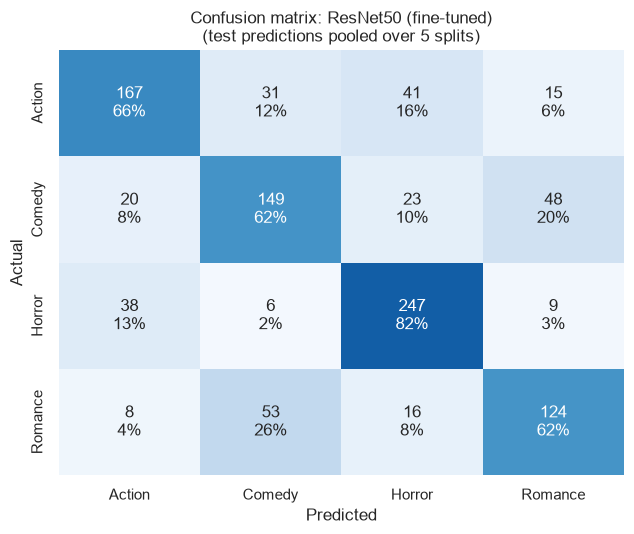

In [11]:
key = (lambda s: ("finetuned", s)) if use_finetuned else (lambda s: (best_backbone, s))
y_true = np.concatenate([preds[key(s)][0] for s in SPLIT_SEEDS])
y_pred = np.concatenate([preds[key(s)][1] for s in SPLIT_SEEDS])
print(f"{final_name}: pooled test accuracy {100 * (y_true == y_pred).mean():.1f}% over {len(y_true)} predictions\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

cm = confusion_matrix(y_true, y_pred)
cm_pct = cm / cm.sum(axis=1, keepdims=True)
annot = np.array([[f"{c}\n{p:.0%}" for c, p in zip(rc, rp)] for rc, rp in zip(cm, cm_pct)])
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(cm_pct, annot=annot, fmt="", cmap="Blues", vmin=0, vmax=1, cbar=False,
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set(title=f"Confusion matrix: {final_name}\n(test predictions pooled over 5 splits)", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.savefig(ASSETS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

### Sample predictions
These are random test posters from split 0. A green title means the prediction was correct, and red means it was wrong.

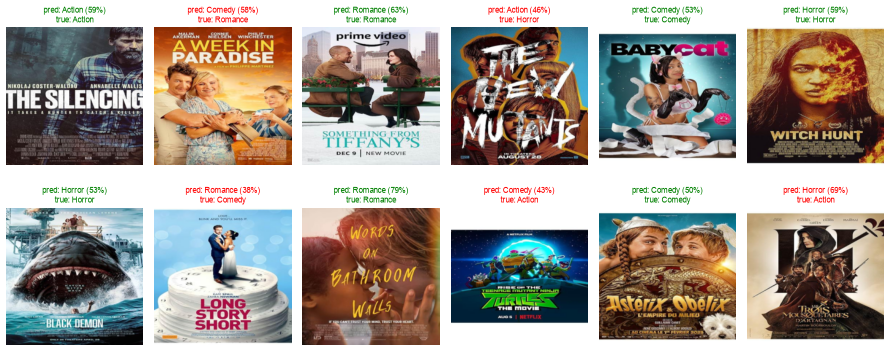

In [12]:
test_paths, test_labels = stratified_split(paths, labels, SPLIT_SEEDS[0])["test"]
_, _, probs0 = preds[key(SPLIT_SEEDS[0])]
idx = random.Random(7).sample(range(len(test_paths)), 12)
with plt.rc_context({"figure.dpi": 60}):
    fig, axes = plt.subplots(2, 6, figsize=(15, 6.5))
    for ax, i in zip(axes.flat, idx):
        ax.imshow(cache[test_paths[i]])
        ax.axis("off")
        pred = probs0[i].argmax()
        ax.set_title(f"pred: {class_names[pred]} ({probs0[i].max():.0%})\ntrue: {class_names[test_labels[i]]}",
                     color="green" if pred == test_labels[i] else "red", fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Save the demo model and run inference

The final configuration trained on split 0 is saved for the [Gradio demo](app.py). Only the weights that training changed are stored, and the frozen pretrained weights are downloaded from torchvision when the model loads.

In [13]:
if not use_finetuned:
    demo_state = states[best_backbone, SPLIT_SEEDS[0]]
demo_state = {k: (v.half() if v.is_floating_point() else v) for k, v in demo_state.items()}  # fp16 halves the file size
torch.save(demo_state, MODELS / "poster_genre.pth")
split0 = runs[(runs["Backbone"] == best_backbone) & (runs["Split"] == SPLIT_SEEDS[0])].iloc[0]
card = {"backbone": best_backbone, "fine_tuned": bool(use_finetuned), "classes": class_names,
        "split_seed": SPLIT_SEEDS[0],
        "test_acc_split0": float(ft.loc[SPLIT_SEEDS[0], "Fine-tuned test acc"] if use_finetuned else split0["Test acc"]),
        "test_acc_mean_5_splits": float(ft.loc["mean", "Fine-tuned test acc"] if use_finetuned else stage1.loc[best_backbone, "Test acc"])}
(MODELS / "model_card.json").write_text(json.dumps(card, indent=2), encoding="utf-8")
print(f"saved {MODELS / 'poster_genre.pth'} ({(MODELS / 'poster_genre.pth').stat().st_size / 1e6:.1f} MB)")
print(json.dumps(card, indent=2))

saved models\poster_genre.pth (30.1 MB)
{
  "backbone": "ResNet50",
  "fine_tuned": true,
  "classes": [
    "Action",
    "Comedy",
    "Horror",
    "Romance"
  ],
  "split_seed": 0,
  "test_acc_split0": 69.34673366834171,
  "test_acc_mean_5_splits": 69.04522613065326
}


In [14]:
from postergenre.models import load_trained_state

demo_model = load_trained_state(build_model(best_backbone, len(class_names)), torch.load(MODELS / "poster_genre.pth")).float().to(device).eval()

@torch.no_grad()
def predict_poster(path, model=demo_model):
    x = eval_tf(Image.open(path).convert("RGB")).unsqueeze(0).to(device)
    return pd.Series(model(x).softmax(1).squeeze().cpu().numpy(), index=class_names).sort_values(ascending=False)

example = test_paths[0]
print("Poster:", Path(example).name, "| true genre:", class_names[test_labels[0]])
predict_poster(example).map("{:.1%}".format)

Poster: tt2943178.jpg | true genre: Action


Action     95.5%
Comedy      2.7%
Horror      1.4%
Romance     0.3%
dtype: str

## 7. Takeaways

In [15]:
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
per_class = pd.DataFrame(report).T.loc[class_names, ["precision", "recall", "f1-score"]]
off = cm.copy(); np.fill_diagonal(off, 0)
a, b = np.unravel_index(off.argmax(), off.shape)
print(f"Best frozen backbone : {best_backbone}  test {stage1.loc[best_backbone, 'Test acc']:.1f}% ± {stage1.loc[best_backbone, 'Test acc sd']:.1f}")
print(f"Backbone ranking     : " + " > ".join(f"{b_} ({stage1.loc[b_, 'Test acc']:.1f}%)" for b_ in stage1.sort_values('Test acc', ascending=False).index))
print(f"Fine-tuning effect   : val {val_gain.mean():+.1f} pts, test {test_gain.mean():+.1f} pts (mean over 5 splits)")
print(f"Final configuration  : {final_name}, pooled test accuracy {100 * (y_true == y_pred).mean():.1f}%")
print(f"Easiest / hardest    : {per_class['f1-score'].idxmax()} (F1 {per_class['f1-score'].max():.2f}) / "
      f"{per_class['f1-score'].idxmin()} (F1 {per_class['f1-score'].min():.2f})")
print(f"Top confusion        : {class_names[a]} -> {class_names[b]} ({cm_pct[a, b]:.0%} of {class_names[a]} posters)")

Best frozen backbone : ResNet50  test 69.6% ± 1.2
Backbone ranking     : ResNet50 (69.6%) > DenseNet121 (66.1%) > ResNet18 (65.7%) > VGG16 (64.1%)
Fine-tuning effect   : val +0.8 pts, test -0.6 pts (mean over 5 splits)
Final configuration  : ResNet50 (fine-tuned), pooled test accuracy 69.0%
Easiest / hardest    : Horror (F1 0.79) / Comedy (F1 0.62)
Top confusion        : Romance -> Comedy (26% of Romance posters)


- **ResNet50 is the best frozen feature extractor: 69.6% ± 1.2 test accuracy** across 5 splits, about 2.8× the 25% random baseline. It also has the smallest spread. DenseNet121 (66.1%), ResNet18 (65.7%) and VGG16 (64.1%) trail by 3.5–5.5 points.
- **A bigger backbone isn't automatically better.** VGG16 has 6× more parameters than ResNet50 but ranks last, and its validation loss stops improving early: its best epoch was ≤ 5 on every split.
- **Single splits mislead.** Individual runs range from 61% to 72% test accuracy. ResNet18 scored 72.4% on one split and 61.3% on another. A single 199-image test set can make the wrong model look best.
- **Regularized fine-tuning no longer overfits badly** (86% train accuracy, compared with 94% in the earlier version), **but it doesn't help either**: +0.8 points on validation and −0.6 on test, both well inside the noise. The frozen ImageNet features already capture most of what 927 training posters can teach. Following the protocol, the fine-tuned model (higher mean validation accuracy) is the final configuration.
- **Per genre:** Horror is the most recognisable genre (F1 0.79, with dark palettes and distinctive typography). Comedy and Romance are the hardest (F1 ≈ 0.62) and are most often confused with each other, since romantic comedies blur the line between them.
- **Next steps:** more data, multi-label genres (a poster can be a romantic comedy), or poster-specific signals such as OCR'd title text and colour statistics.